**Лабораторная работа №3. Геометрические преобразования изображений**

Выполнили студенты группы 932302: Лебёдкин Владислав и Травкова Ирина

Вариант 4

In [2]:
#импорт библиотек
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

(np.float64(-0.5), np.float64(739.5), np.float64(739.5), np.float64(-0.5))

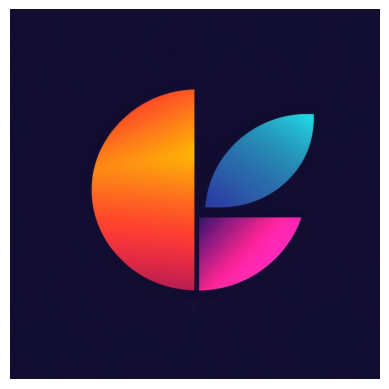

In [3]:
#чтение изображения
original_image = cv2.imread("abstract.jpg")
changing_image = cv2.cvtColor(original_image,cv2.COLOR_BGR2RGB)
plt.imshow(changing_image)
plt.axis("off")

### 1. Масштабировать изображение в 0.25 раза (уменьшить в 4 раза).

Для уменьшения изображения в 4 раза используется `cv2.resize()`: **fx, fy** - коэффициенты масштабирования по ширине и высоте; флаг **interpolation**- необязательный параметр, отвечающий за метод интерполяции. `cv2.INTER_LINEAR` отвечает за билинейную интерполяцию (Общее изменение размера)

In [4]:
resized_025 = cv2.resize(changing_image, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_LINEAR)

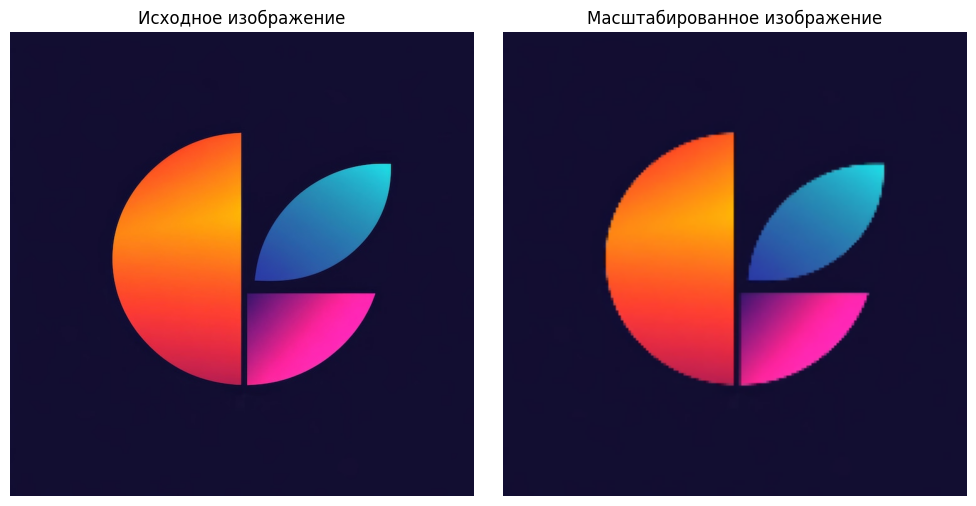

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(resized_025)
ax2.set_title('Масштабированное изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()


### 2. Повернуть изображение на 180°.

Вращение изображения относится к **аффинным преобразованиям**, которые сохраняют параллельность прямых, коллинеарность точек и отношение длин отрезков. 

Сначала вычисляем координаты центра изображения, а затем с помощью `cv2.getRotationMatrix2D(center, angle, scale)` формируем матрицу аффинного преобразования для поворота, где: 

* center - центр изображения, 
* angle - угол поворота в градусах (**180**). В OpenCV положительное значение означает поворот **против часовой стрелки**, но для $180^\circ$ направление симметрично. 
* scale — коэффициент масштабирования (**1.0**), чтобы сохранить исходные пропорции. 

Функция `cv2.warpAffine(img, M, (w, h))` применяет преобразование. Она использует **обратное отображение координат** и билинейную интерполяцию по умолчанию, что гарантирует отсутствие «дыр» и артефактов в результирующем массиве.

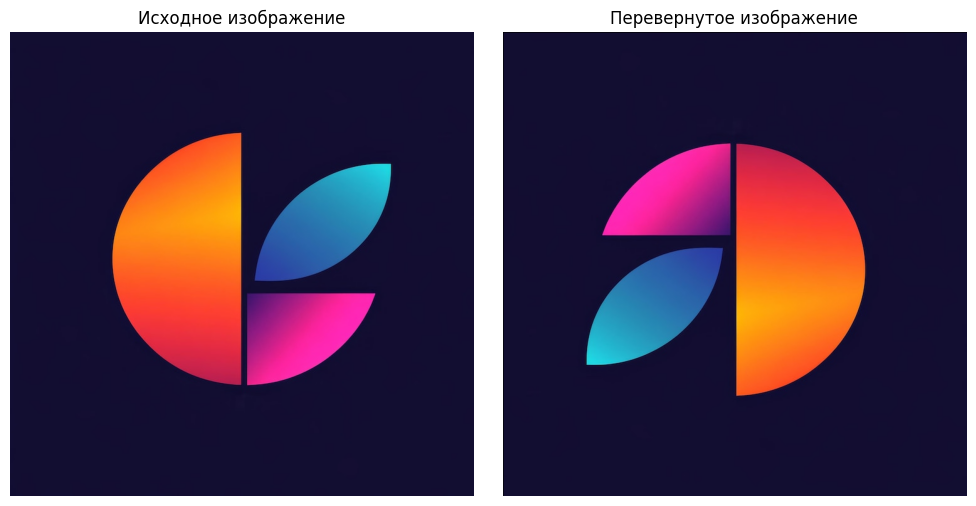

In [6]:
#вычисляем координаты центра изображения
h, w = changing_image.shape[:2]
center = (w // 2, h // 2)

#формируем матрицу аффинного преобразования для поворота
M_rot = cv2.getRotationMatrix2D(center, 180, 1.0)

#применяем преобразование
rotated_180 = cv2.warpAffine(changing_image, M_rot, (w, h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(rotated_180)
ax2.set_title('Перевернутое изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()

### 3. Сместить изображение на 150 пикселей вправо.

Сдвиг изображения относится к аффинным преобразованиям. Для перемещения на 150 пикселей вправо создаём матрицу размером 2 × 3 с помощью np.float32(), где:
- 150 в последнем столбце первой строки задаёт смещение по горизонтали;
- 0 в последнем столбце второй строки означает отсутствие смещения по вертикали;
- единицы на главной диагонали сохраняют масштаб изображения.
Функция cv2.warpAffine(changing_image, matrix, (w, h)) применяет преобразование, где (w, h) — ширина и высота результата. Размер кадра остаётся прежним: слева появляется чёрная полоса, а часть изображения, вышедшая за правую границу, обрезается.

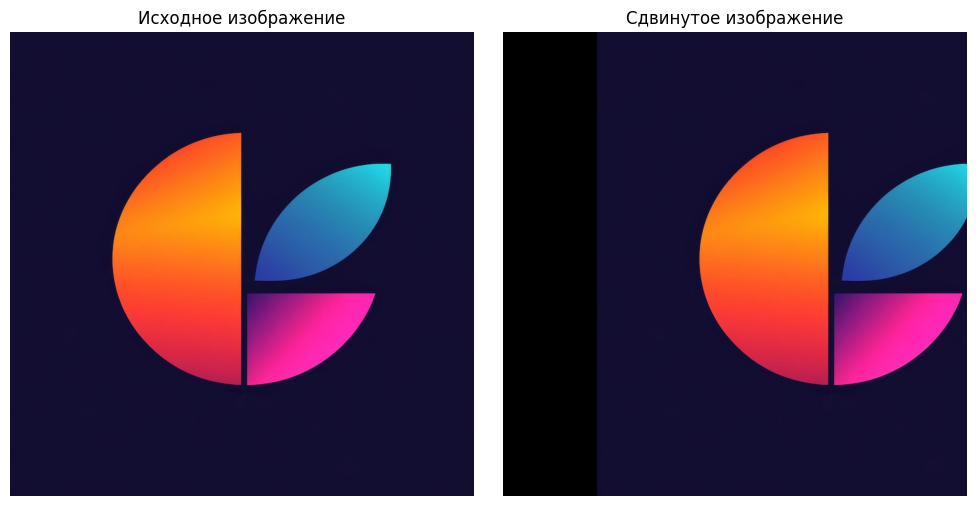

In [10]:
matrix = np.float32([[1, 0, 150],
          [0, 1, 0]])

shifted_image = cv2.warpAffine(changing_image,matrix,(w,h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(shifted_image)
ax2.set_title('Сдвинутое изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()

### 4. Отразить изображение относительно обеих осей сразу.
Для отражения используется cv2.flip(changing_image, flipCode), где changing_image — исходное изображение, а flipCode определяет направление отражения:
- 0 — относительно горизонтальной оси: верхняя и нижняя части меняются местами;
- 1 — относительно вертикальной оси: левая и правая части меняются местами;
- −1 — относительно обеих осей одновременно.
В работе используется значение −1. Такое отражение соответствует повороту на 180° вокруг центра сетки пикселей. Функция переставляет пиксели без интерполяции, поэтому их значения и размер изображения сохраняются.

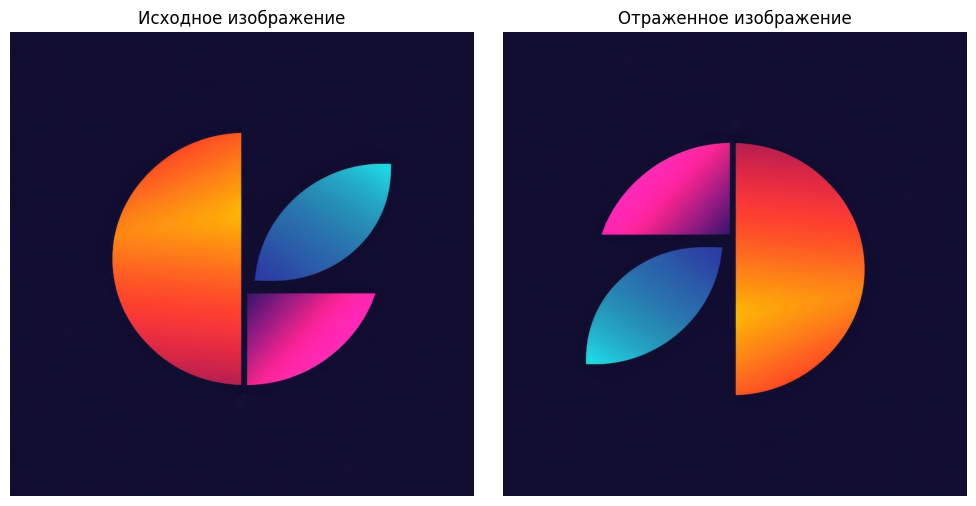

In [16]:
mirror_image = cv2.flip(changing_image,-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(mirror_image)
ax2.set_title('Отраженное изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()

### 5. Выполнить перспективное преобразование для объекта на изображении
Перспективное преобразование позволяет отобразить выбранную четырёхугольную область на прямоугольник. Сначала задаём два массива координат типа np.float32:
- src_points — четыре точки на исходном изображении;
- dst_points — соответствующие им точки результата. В работе это углы выходного кадра: [0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1].
Точки в обоих массивах должны соответствовать друг другу по порядку. Функция cv2.getPerspectiveTransform(src_points, dst_points) вычисляет матрицу преобразования размером 3 × 3.
Затем cv2.warpPerspective(changing_image, matrix, (w, h)) применяет преобразование и создаёт изображение заданной ширины и высоты. Выбранная область растягивается на весь кадр. В данном коде исходные точки охватывают только часть фигуры, поэтому результат показывает увеличенный и искажённый фрагмент.

740 740


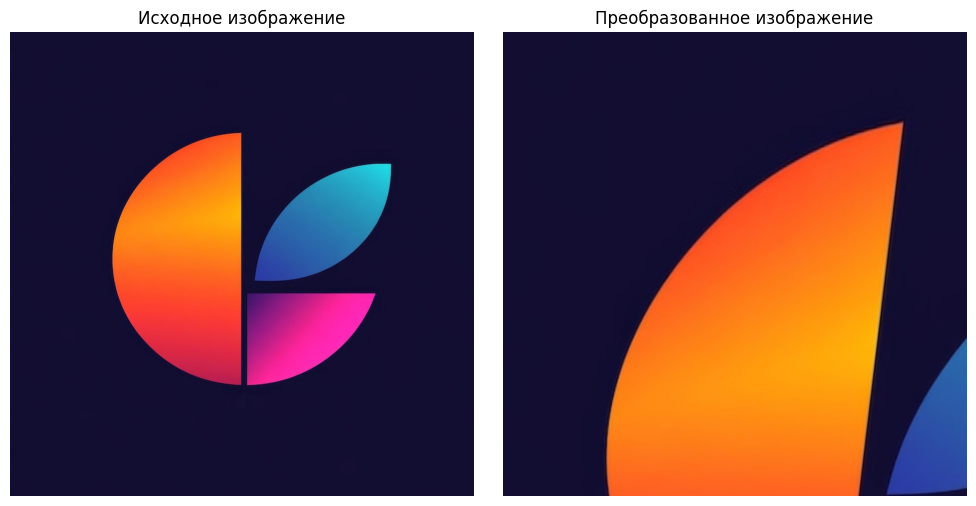

In [20]:
print(h,w)

src_points = np.float32([
    [100, 80],   
    [400, 120],   
    [450, 400],   
    [70, 380]     
])


dst_points = np.float32([
    [0, 0],
    [w - 1, 0],
    [w - 1, h - 1],
    [0, h - 1]
])

matrix = cv2.getPerspectiveTransform(src_points, dst_points)

point_image = cv2.warpPerspective(changing_image, matrix, (w, h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(point_image)
ax2.set_title('Преобразованное изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()

**ОТВЕТЫ НА КОНТРОЛЬНЫЕ ВОПРОСЫ:**
1. *Какой эффект даёт уменьшение изображения с коэффициентом 0.25?* Уменьшение изображения в 0.25 раза по каждой оси означает, что его линейные размеры (ширина и высота) сокращаются в 4 раза, а общее количество пикселей уменьшается в 16 раз (0.25×0.25=0.0625 от исходного объёма). К основным эффектам относятся: потеря мелких деталей и высокочастотных компонентов, снижение вычислительной нагрузки и сохранение пропорций.
2. *Сколько точек нужно для перспективного преобразования?* Для перспективного преобразования нужно 4 пары точек, так как матрица гомографии имеет 8 неизвестных параметров. Четыре точки дают ровно 8 уравнений, что позволяет однозначно решить систему. В коде это реализовано через cv2.getPerspectiveTransform, где мы задаём углы исходной трапеции и целевого прямоугольника.